# Figure Reproduction Instructions

This notebook contains complete instructions for reproducing all figures used in the Civil Rights Summarized AI project report and presentation.

## Prerequisites

Before running this notebook, complete the setup in [INSTALL.md](../INSTALL.md):

```bash
# From repository root
pip install -e ".[ml]"
```

## Data Requirements

- **Figures 1 & 2** use fixture data bundled in `data/fixtures/` — no downloads needed.
- **Figures 3 & 4** will automatically fall back to precomputed fixtures in `data/fixtures/` if no evaluation results are present. To use your own results, run the evaluation pipeline (see instructions below).

## Figures Overview

| Figure | Title | Used In | Data Source |
|--------|-------|---------|-------------|
| 1 | Training Loss Curve | Report, Presentation | `data/fixtures/trainer_state.json` |
| 2 | Document Fragmentation Distribution | Report | `data/fixtures/test_chunk_counts.json` |
| 3 | Evaluation Metrics Comparison | Report | `eval/results/summary_*.json` (or `data/fixtures/eval_summary.json`) |
| 4 | LLM-as-Judge Score Distribution | Report | `eval/results/scores_*.jsonl` (or `data/fixtures/eval_scores.jsonl`) |

## Setup

In [13]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Resolve paths relative to the repository root
NOTEBOOK_DIR = Path(".").resolve()
ROOT = NOTEBOOK_DIR.parent  # repository root
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Consistent styling
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 100,
})

print(f"Repository root: {ROOT}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Repository root: /Users/liamsandy/Documents/Legal/CivilRightsSummarizedAI
Figures will be saved to: /Users/liamsandy/Documents/Legal/CivilRightsSummarizedAI/figures


---

## Figure 1: Training Loss Curve

**Description:** Shows the training loss over the course of LoRA fine-tuning of the Qwen2.5-7B-Instruct model. This figure demonstrates model convergence and is used in the final report and project presentation to illustrate the training process.

**Data source:** `data/fixtures/trainer_state.json` (38 KB extract from the training checkpoint).  
This file contains per-step metrics saved by Hugging Face's Trainer during training.

**Prerequisites:** None — the fixture file is included in the repository.

In [14]:
# Load training history from the bundled fixture
trainer_state_path = ROOT / "data" / "fixtures" / "trainer_state.json"

with open(trainer_state_path) as f:
    trainer_state = json.load(f)

log_history = trainer_state["log_history"]

# Extract steps and loss (filter to entries that have 'loss' key)
steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]
accuracies = [entry["mean_token_accuracy"] for entry in log_history if "mean_token_accuracy" in entry]

print(f"Total training steps: {trainer_state['global_step']}")
print(f"Log entries with loss: {len(steps)}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Final token accuracy: {accuracies[-1]:.4f}")

Total training steps: 1231
Log entries with loss: 123
Final loss: 25.2507
Final token accuracy: 0.0640


Saved: /Users/liamsandy/Documents/Legal/CivilRightsSummarizedAI/figures/figure1_training_loss.png


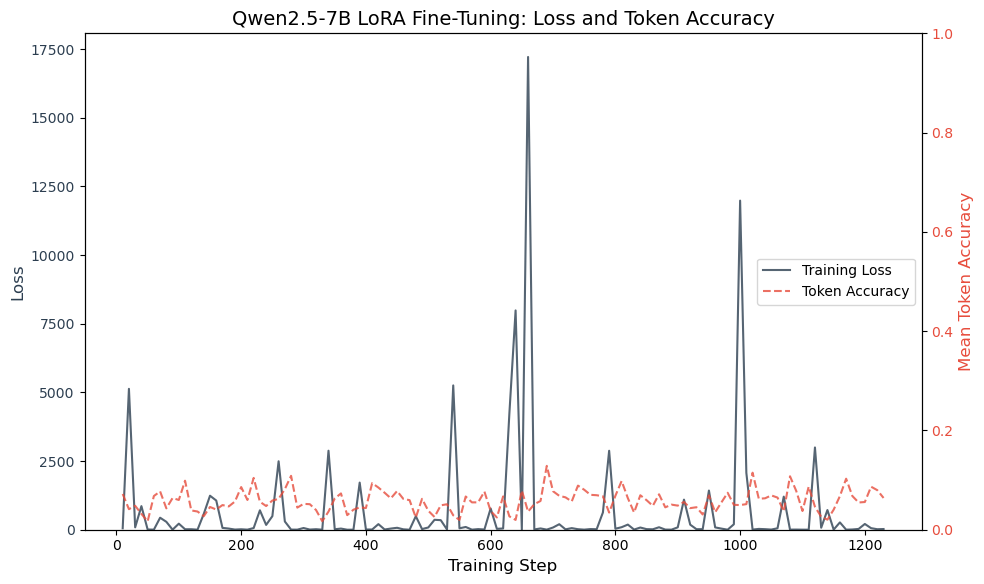

In [15]:
# Generate Figure 1: Training Loss Curve
fig, ax1 = plt.subplots(figsize=(10, 6))

color_loss = "#2c3e50"
color_acc = "#e74c3c"

# Plot loss on primary y-axis
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss", color=color_loss)
ax1.plot(steps, losses, color=color_loss, linewidth=1.5, alpha=0.8, label="Training Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)
ax1.set_ylim(bottom=0)

# Plot token accuracy on secondary y-axis
ax2 = ax1.twinx()
ax2.set_ylabel("Mean Token Accuracy", color=color_acc)
acc_steps = [entry["step"] for entry in log_history if "mean_token_accuracy" in entry]
ax2.plot(acc_steps, accuracies, color=color_acc, linewidth=1.5, alpha=0.8, linestyle="--", label="Token Accuracy")
ax2.tick_params(axis="y", labelcolor=color_acc)
ax2.set_ylim(0, 1)

# Title and legend
plt.title("Qwen2.5-7B LoRA Fine-Tuning: Loss and Token Accuracy")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig.tight_layout()

# Export
fig.savefig(FIGURES_DIR / "figure1_training_loss.png", dpi=300, bbox_inches="tight")
print(f"Saved: {FIGURES_DIR / 'figure1_training_loss.png'}")
plt.show()

---

## Figure 2: Document Fragmentation Distribution

**Description:** Histogram showing the distribution of document fragment counts per case in the test dataset. This illustrates the core challenge of the project: legal cases are composed of varying numbers of source documents (complaints, motions, orders, etc.) that must be synthesized into a single coherent summary.

**Data source:** `data/fixtures/test_chunk_counts.json` (61 KB extract with chunk-count fields from all 1,231 test records).

**Prerequisites:** None — the fixture file is included in the repository.

In [16]:
# Load chunk counts from the bundled fixture
chunk_counts_path = ROOT / "data" / "fixtures" / "test_chunk_counts.json"

with open(chunk_counts_path) as f:
    chunk_data = json.load(f)

source_chunks = [r["source_chunk_count"] for r in chunk_data]
used_chunks = [r["used_chunk_count"] for r in chunk_data]

print(f"Total test records: {len(source_chunks)}")
print(f"Source chunk count — min: {min(source_chunks)}, max: {max(source_chunks)}, mean: {sum(source_chunks)/len(source_chunks):.1f}")
print(f"Used chunk count   — min: {min(used_chunks)}, max: {max(used_chunks)}, mean: {sum(used_chunks)/len(used_chunks):.1f}")

Total test records: 1231
Source chunk count — min: 1, max: 405, mean: 11.6
Used chunk count   — min: 1, max: 405, mean: 11.6


Saved: /Users/liamsandy/Documents/Legal/CivilRightsSummarizedAI/figures/figure2_fragmentation_distribution.png


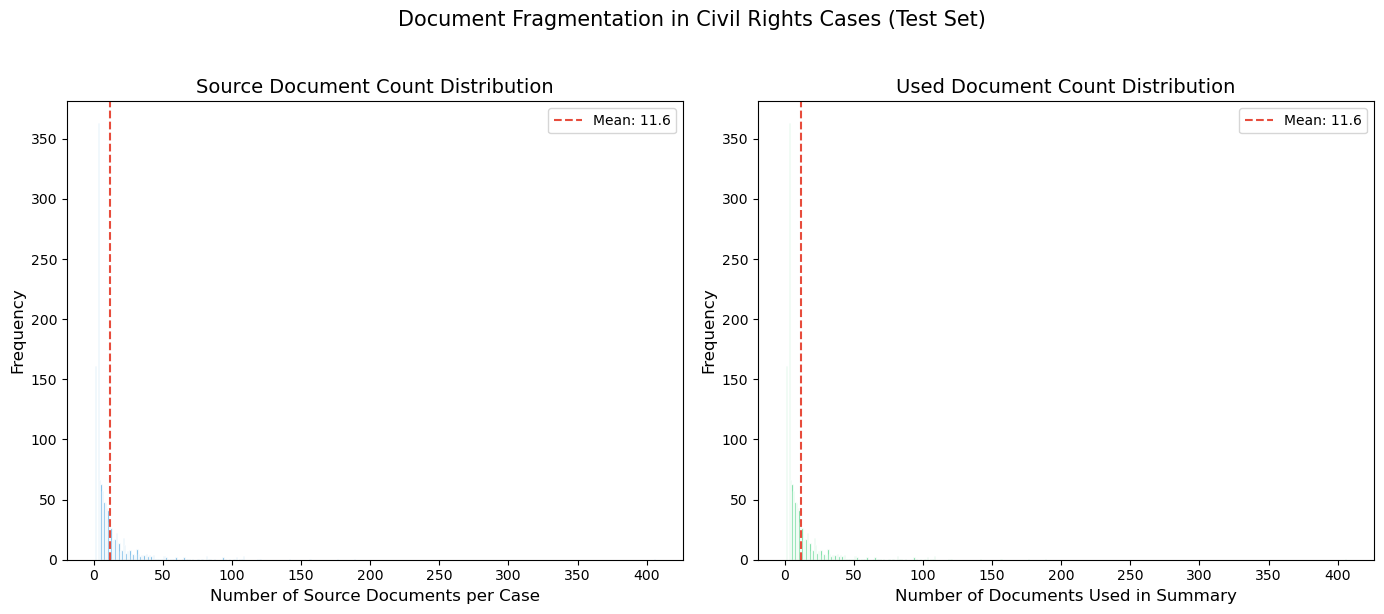

In [17]:
# Generate Figure 2: Document Fragmentation Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Source chunk count histogram
ax1.hist(source_chunks, bins=range(1, max(source_chunks) + 2), color="#3498db", edgecolor="white", alpha=0.85)
ax1.set_xlabel("Number of Source Documents per Case")
ax1.set_ylabel("Frequency")
ax1.set_title("Source Document Count Distribution")
ax1.axvline(sum(source_chunks)/len(source_chunks), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mean: {sum(source_chunks)/len(source_chunks):.1f}")
ax1.legend()

# Used chunk count histogram
ax2.hist(used_chunks, bins=range(1, max(used_chunks) + 2), color="#2ecc71", edgecolor="white", alpha=0.85)
ax2.set_xlabel("Number of Documents Used in Summary")
ax2.set_ylabel("Frequency")
ax2.set_title("Used Document Count Distribution")
ax2.axvline(sum(used_chunks)/len(used_chunks), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mean: {sum(used_chunks)/len(used_chunks):.1f}")
ax2.legend()

fig.suptitle("Document Fragmentation in Civil Rights Cases (Test Set)", fontsize=15, y=1.02)
fig.tight_layout()

# Export
fig.savefig(FIGURES_DIR / "figure2_fragmentation_distribution.png", dpi=300, bbox_inches="tight")
print(f"Saved: {FIGURES_DIR / 'figure2_fragmentation_distribution.png'}")
plt.show()

---

## Figures 3 & 4: Evaluation Pipeline Results

Figures 3 and 4 require running the evaluation pipeline to generate summaries and score them.

### Step 1: Generate Summaries

Run from the repository root. Choose one or both sources:

```bash
# Generate summaries using the fine-tuned local model (requires GPU + model weights)
cd eval
python generate.py --source local --sample 50

# OR generate summaries using Claude API (requires ANTHROPIC_API_KEY env var)
cd eval
python generate.py --source claude --sample 50
```

**Time estimate:** ~30 min for local (50 samples on GPU), ~5 min for Claude API.

Output: `eval/results/generations_{source}_{timestamp}.jsonl`

### Step 2: Evaluate Summaries

```bash
cd eval
python evaluate.py results/generations_local_*.jsonl --judge-sample 25
```

**Time estimate:** ~10 min (ROUGE + BERTScore + LLM judge on 25 samples).

Output:
- `eval/results/scores_{name}_{timestamp}.jsonl` (per-record scores)
- `eval/results/summary_{name}_{timestamp}.json` (aggregate statistics)

### Using Pre-computed Results

If pre-computed results are available (e.g., from shared Teams directory), place them in `eval/results/` and skip Steps 1-2. Update the file paths in the cells below accordingly.

In [18]:
# Find the most recent evaluation results
results_dir = ROOT / "eval" / "results"
fixtures_dir = ROOT / "data" / "fixtures"

summary_files = sorted(results_dir.glob("summary_*.json"))
scores_files = sorted(results_dir.glob("scores_*.jsonl"))

# Fall back to precomputed fixtures if no eval results exist
using_fixtures = False
if not summary_files:
    fixture_summary = fixtures_dir / "eval_summary.json"
    if fixture_summary.exists():
        summary_files = [fixture_summary]
        using_fixtures = True

if not scores_files:
    fixture_scores = fixtures_dir / "eval_scores.jsonl"
    if fixture_scores.exists():
        scores_files = [fixture_scores]
        using_fixtures = True

if using_fixtures:
    print("No evaluation results found in eval/results/ — using precomputed fixtures from data/fixtures/.")
    print("To use your own results, run the evaluation pipeline (Steps 1-2 above).\n")

if not summary_files:
    print("No summary files found (checked eval/results/ and data/fixtures/).")
else:
    print(f"Found {len(summary_files)} summary file(s):")
    for f in summary_files:
        print(f"  {f.name}")

if not scores_files:
    print("No scores files found (checked eval/results/ and data/fixtures/).")
else:
    print(f"Found {len(scores_files)} scores file(s):")
    for f in scores_files:
        print(f"  {f.name}")

No evaluation results found in eval/results/ — using precomputed fixtures from data/fixtures/.
To use your own results, run the evaluation pipeline (Steps 1-2 above).

Found 1 summary file(s):
  eval_summary.json
Found 1 scores file(s):
  eval_scores.jsonl


---

## Figure 3: Evaluation Metrics Comparison

**Description:** Bar chart comparing ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore F1 metrics across evaluation runs. This figure is used in the report results section to show how well the model's generated summaries match human-written reference summaries.

**Data source:** `eval/results/summary_*.json` — aggregate statistics from the evaluation pipeline.

**Fallback:** If no eval results exist, precomputed fixtures from `data/fixtures/eval_summary.json` are used automatically.

**Prerequisites:** None when using fixtures. To use your own data, run the evaluation pipeline (Steps 1-2 above).

Saved: /Users/liamsandy/Documents/Legal/CivilRightsSummarizedAI/figures/figure3_evaluation_metrics.png


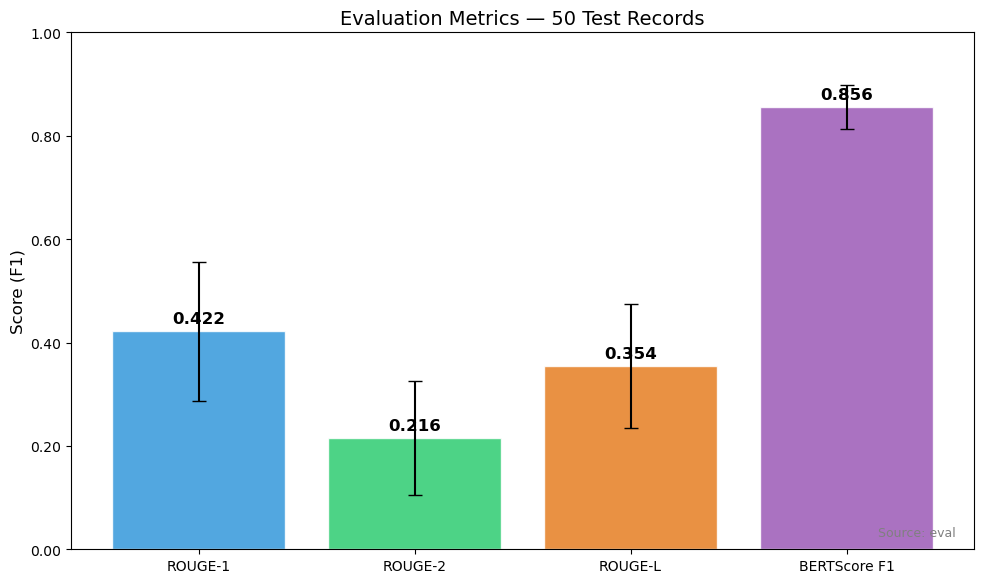

In [19]:
# Generate Figure 3: Evaluation Metrics Comparison
if not summary_files:
    print("Skipping Figure 3 — no evaluation results available.")
else:
    # Load the most recent summary
    summary_path = summary_files[-1]
    with open(summary_path) as f:
        summary = json.load(f)

    # Extract metrics
    metric_labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore F1"]
    metric_keys = ["rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1"]
    means = []
    stds = []

    for key in metric_keys:
        if key in summary:
            means.append(summary[key]["mean"])
            stds.append(summary[key]["std"])
        else:
            means.append(0)
            stds.append(0)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]
    bars = ax.bar(metric_labels, means, yerr=stds, capsize=5, color=colors, edgecolor="white", alpha=0.85)

    # Add value labels on bars
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{mean:.3f}", ha="center", va="bottom", fontweight="bold")

    ax.set_ylabel("Score (F1)")
    ax.set_title(f"Evaluation Metrics — {summary.get('n_records', '?')} Test Records")
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    source_name = summary_path.stem.replace("summary_", "").rsplit("_", 2)[0]
    ax.annotate(f"Source: {source_name}", xy=(0.98, 0.02), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="gray")

    fig.tight_layout()

    # Export
    fig.savefig(FIGURES_DIR / "figure3_evaluation_metrics.png", dpi=300, bbox_inches="tight")
    print(f"Saved: {FIGURES_DIR / 'figure3_evaluation_metrics.png'}")
    plt.show()

---

## Figure 4: LLM-as-Judge Score Distribution

**Description:** Box plots showing the distribution of LLM-as-Judge scores across five evaluation dimensions: Factual Accuracy, Completeness, Conciseness & Style, Legal Reasoning, and Overall Quality. Each dimension is scored on a 1-5 scale by Claude acting as an expert legal editor.

**Data source:** `eval/results/scores_*.jsonl` — per-record evaluation scores from the evaluation pipeline.

**Fallback:** If no eval results exist, precomputed fixtures from `data/fixtures/eval_scores.jsonl` are used automatically.

**Prerequisites:** None when using fixtures. To use your own data, run the evaluation pipeline with LLM judge enabled (do NOT use `--skip-judge`).

Saved: /Users/liamsandy/Documents/Legal/CivilRightsSummarizedAI/figures/figure4_judge_scores.png


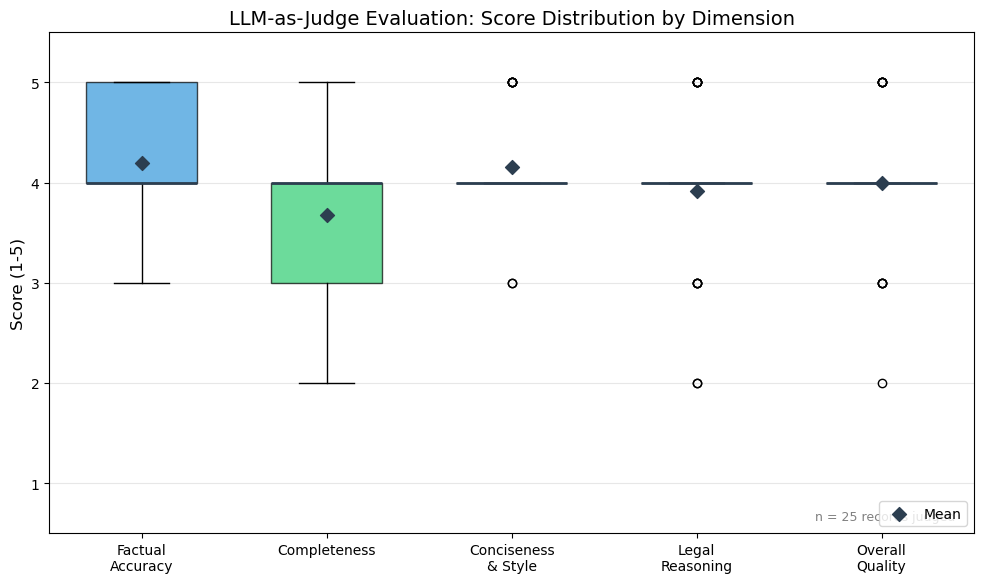

In [20]:
# Generate Figure 4: LLM-as-Judge Score Distribution
if not scores_files:
    print("Skipping Figure 4 — no scores files available.")
else:
    # Load the most recent scores file
    scores_path = scores_files[-1]
    records = []
    with open(scores_path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))

    # Extract judge scores
    judge_dims = {
        "judge_factual_accuracy": "Factual\nAccuracy",
        "judge_completeness": "Completeness",
        "judge_conciseness_style": "Conciseness\n& Style",
        "judge_legal_reasoning": "Legal\nReasoning",
        "judge_overall": "Overall\nQuality",
    }

    data = []
    labels = []
    for key, label in judge_dims.items():
        vals = [r[key] for r in records if key in r and r[key] is not None]
        if vals:
            data.append(vals)
            labels.append(label)

    if not data:
        print("No LLM judge scores found in the scores file.")
        print("Make sure evaluation was run without --skip-judge.")
    else:
        fig, ax = plt.subplots(figsize=(10, 6))

        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
                        medianprops={"color": "#2c3e50", "linewidth": 2})

        colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c"]
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Add mean markers
        means = [sum(d)/len(d) for d in data]
        ax.scatter(range(1, len(means)+1), means, color="#2c3e50", marker="D", s=50, zorder=3, label="Mean")

        ax.set_ylabel("Score (1-5)")
        ax.set_title("LLM-as-Judge Evaluation: Score Distribution by Dimension")
        ax.set_ylim(0.5, 5.5)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.legend(loc="lower right")
        ax.grid(axis="y", alpha=0.3)

        n_judged = len(data[0])
        ax.annotate(f"n = {n_judged} records judged", xy=(0.98, 0.02), xycoords="axes fraction",
                    ha="right", va="bottom", fontsize=9, color="gray")

        fig.tight_layout()

        # Export
        fig.savefig(FIGURES_DIR / "figure4_judge_scores.png", dpi=300, bbox_inches="tight")
        print(f"Saved: {FIGURES_DIR / 'figure4_judge_scores.png'}")
        plt.show()

---

## Summary of Exported Figures

All figures are saved to the `figures/` directory at the repository root:

In [21]:
# List all exported figures
exported = sorted(FIGURES_DIR.glob("figure*.png"))
if exported:
    print("Exported figures:")
    for f in exported:
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name} ({size_kb:.0f} KB)")
else:
    print("No figures exported yet. Run the cells above to generate them.")

Exported figures:
  figure1_training_loss.png (291 KB)
  figure2_fragmentation_distribution.png (175 KB)
  figure3_evaluation_metrics.png (101 KB)
  figure4_judge_scores.png (118 KB)
